# Mass vs Radius

In [1]:
from cProfile import label

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as st

from numpy import log10
from matplotlib.lines import lineStyles
from openpyxl.styles.builtins import styles

In [2]:
data = {
    'Hypothesis': ['H0', 'H1'],
    'Mass vs Radius': ['There is no relationship between planet_mass_earth and planet_radius_earth', 'Greater mass = larger radius (non-linear relationship)']
}
mass_vs_radius = pd.DataFrame(data)
mass_vs_radius

,Hypothesis,Mass vs Radius
0,H0,There is no relationship between planet_mass_e...
1,H1,Greater mass = larger radius (non-linear relat...


We are testing this hypothesis because there may be planets with a very large radius but low mass (gas giants). There may also be planets with a small radius but very high mass.

In [3]:
# Load the dataset
data = pd.read_csv('../data/nasa_exoplanet_intelligence.csv')
data

,planet_name,host_star,n_stars,n_planets,discovery_method,disc_year,disc_facility,orbital_period_days,planet_radius_earth,planet_mass_earth,...,ra,dec,controversial_flag,planet_type,habitable_zone_flag,multi_planet_system,is_recent_discovery,dist_category,star_type,orbital_period_cat
0,Kepler-1167 b,Kepler-1167,1,1,Transit,2016.0,Kepler,1.003934,1.710000,3.570000,...,298.302660,47.693965,0,Super-Earth,False,False,False,Far(500-2kpc),K-type,Short(1-10d)
1,Kepler-1740 b,Kepler-1740,1,1,Transit,2021.0,Kepler,8.172400,3.323214,11.000000,...,293.873663,38.922455,0,Mini-Neptune,False,False,True,Far(500-2kpc),G-type(Sun-like),Short(1-10d)
2,Kepler-1581 b,Kepler-1581,1,1,Transit,2016.0,Kepler,6.283855,0.800000,0.437000,...,287.371320,39.603623,0,Sub-Earth,False,False,False,Mid(100-500pc),F-type,Short(1-10d)
3,Kepler-644 b,Kepler-644,1,1,Transit,2016.0,Kepler,3.173917,3.150000,10.100000,...,295.475702,43.493112,0,Mini-Neptune,False,False,False,Far(500-2kpc),F-type,Short(1-10d)
4,Kepler-1752 b,Kepler-1752,1,1,Transit,2021.0,Kepler,56.358501,4.540605,18.700000,...,290.854140,51.222743,0,Neptune-like,False,False,True,Far(500-2kpc),G-type(Sun-like),Medium(10-100d)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6145,KMT-2024-BLG-1870L b,KMT-2024-BLG-1870L,1,1,Microlensing,2026.0,KMTNet,NaN,13.800000,336.898111,...,272.465333,-26.882889,0,Gas Giant,False,False,True,Distant(2k+pc),Unknown,Unknown
6146,TOI-2267 b,TOI-2267 A,2,3,Transit,2025.0,Transiting Exoplanet Survey Satellite (TESS),2.289090,1.000000,0.972000,...,65.061496,84.900824,0,Super-Earth,False,True,True,Nearby(<100pc),M-type(Red Dwarf),Short(1-10d)
6147,TOI-813 b,TOI-813,1,1,Transit,2020.0,Transiting Exoplanet Survey Satellite (TESS),83.891100,6.710000,36.400000,...,72.694010,-60.905461,0,Gas Giant,False,False,True,Mid(100-500pc),G-type(Sun-like),Medium(10-100d)
6148,LHS 1903 b,LHS 1903,1,4,Transit,2026.0,Transiting Exoplanet Survey Satellite (TESS),2.155510,1.382000,3.280000,...,107.865826,48.327933,0,Super-Earth,False,True,True,Nearby(<100pc),M-type(Red Dwarf),Short(1-10d)


In [4]:
data['planet_mass_earth'].isna().sum()

np.int64(31)

In [5]:
data['planet_radius_earth'].isna().sum()

np.int64(50)

In [6]:
cleaned_data = data[['planet_mass_earth', 'planet_radius_earth']].dropna()

Missing values in the selected features were minimal (~1.5%),
therefore rows containing NaN values were removed to ensure accurate statistical analysis.

In [7]:
cleaned_data['planet_mass_earth'].describe()

count    6076.000000
mean      395.767791
std      1131.865261
min         0.020000
25%         4.160000
50%         9.150000
75%       181.163100
max      9534.852210
Name: planet_mass_earth, dtype: float64

The histogram of the log-transformed planet mass is used to better visualize the distribution, as the original data is highly skewed. The log transformation reduces the impact of extreme values, making the distribution more interpretable. The vertical dashed line represents the mean, indicating the central tendency of the data.

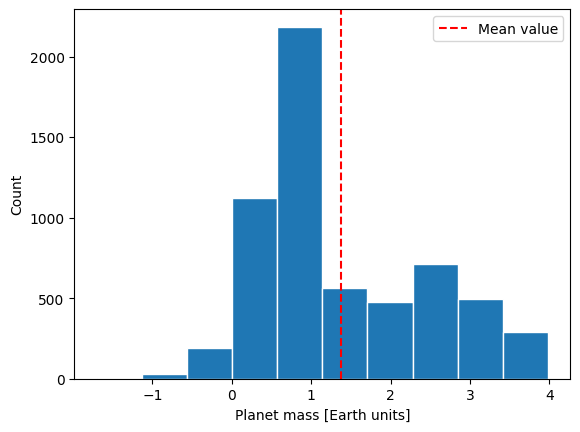

In [8]:
plt.hist(log10(cleaned_data['planet_mass_earth']), edgecolor='white')
mean_value = log10(cleaned_data['planet_mass_earth']).mean()

plt.axvline(mean_value, color='r', linestyle='--', label='Mean value')

plt.xlabel('Planet mass [Earth units]')
plt.ylabel('Count')
plt.legend()
plt.show()

In [9]:
cleaned_data['planet_radius_earth'].describe()

count    6076.000000
mean        5.806160
std         5.407487
min         0.309800
25%         1.820000
50%         2.830000
75%        11.900000
max        87.205870
Name: planet_radius_earth, dtype: float64

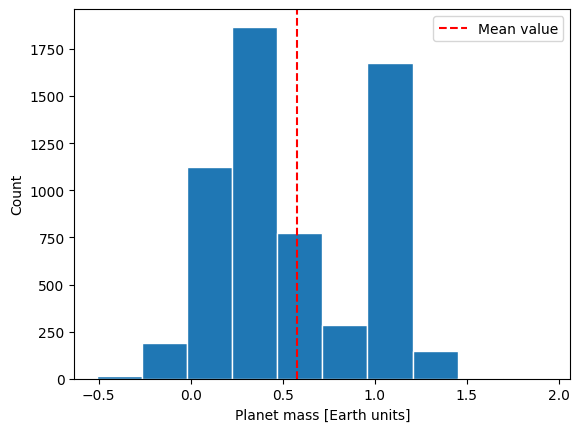

In [10]:
plt.hist(log10(cleaned_data['planet_radius_earth']), edgecolor='white')
mean_value = log10(cleaned_data['planet_radius_earth']).mean()

plt.axvline(mean_value, color='r', linestyle='--', label='Mean value')

plt.xlabel('Planet mass [Earth units]')
plt.ylabel('Count')
plt.legend()
plt.show()

In [11]:
focused_features = cleaned_data[['planet_mass_earth', 'planet_radius_earth']]

In [12]:
st.pearsonr(
    focused_features['planet_mass_earth'],
    focused_features['planet_radius_earth']
)

PearsonRResult(statistic=np.float64(0.4540867226821414), pvalue=np.float64(6.082551772437259e-307))

There is a statistically significant moderate positive correlation between planet mass and planet radius.

As mass increases, radius tends to increase as well, although the relationship is not perfectly linear.

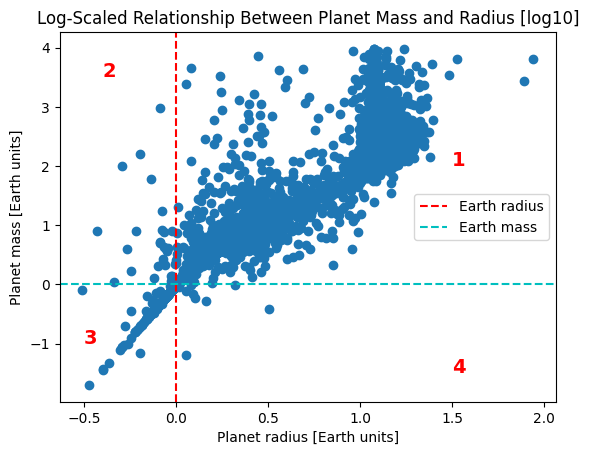

In [13]:
plt.scatter(log10(focused_features['planet_radius_earth']), log10(focused_features['planet_mass_earth']))

plt.axvline(x=0, color='r', linestyle='--', label='Earth radius')
plt.axhline(y=0, color='c', linestyle='--', label='Earth mass')

# Quadrant labels
plt.text(1.5, 2, '1', fontsize=14, fontweight='bold', color='r')
plt.text(-0.4, 3.5, '2', fontsize=14, fontweight='bold', color='r')
plt.text(-0.5, -1, '3', fontsize=14, fontweight='bold', color='r')
plt.text(1.5, -1.5, '4', fontsize=14, fontweight='bold', color='r')

plt.title('Log-Scaled Relationship Between Planet Mass and Radius [log10]')
plt.xlabel('Planet radius [Earth units]')
plt.ylabel('Planet mass [Earth units]')
plt.legend()
plt.show()

**Quadrant 1** - Planets with both larger radius and greater mass than Earth

**Quadrant 2** - Planets with smaller radius but greater mass than Earth

**Quadrant 3** - Planets with both smaller radius and lower mass than Earth

**Quadrant 4** - Planets with larger radius but lower mass than Earth

From the observed exoplanets, we can see that a large proportion are significantly larger than Earth in both size and mass.

A speculative hypothesis - which cannot currently be verified - is that if life similar to that on Earth exists on some of the largest observed planets, their populations could potentially reach billions of inhabitants.

In [14]:
data['log_radius'] = np.log10(data['planet_radius_earth'])
data['log_mass'] = np.log10(data['planet_mass_earth'])

quadrant_1 = data[(data['log_radius'] > 0) & (data['log_mass'] > 0)]

quadrant_2 = data[(data['log_radius'] < 0) & (data['log_mass'] > 0)]

quadrant_3 = data[(data['log_radius'] < 0) & (data['log_mass'] < 0)]

quadrant_4 = data[(data['log_radius'] > 0) & (data['log_mass'] < 0)]

In [15]:
quadrant_3

,planet_name,host_star,n_stars,n_planets,discovery_method,disc_year,disc_facility,orbital_period_days,planet_radius_earth,planet_mass_earth,...,controversial_flag,planet_type,habitable_zone_flag,multi_planet_system,is_recent_discovery,dist_category,star_type,orbital_period_cat,log_radius,log_mass
2,Kepler-1581 b,Kepler-1581,1,1,Transit,2016.0,Kepler,6.283855,0.8000,0.437000,...,0,Sub-Earth,False,False,False,Mid(100-500pc),F-type,Short(1-10d),-0.096910,-0.359519
90,PSR B1257+12 b,PSR B1257+12,1,3,Pulsar Timing,1994.0,Arecibo Observatory,25.262000,0.3380,0.020000,...,0,Sub-Earth,False,True,False,Far(500-2kpc),Unknown,Medium(10-100d),-0.471083,-1.698970
171,KOI-55 b,KOI-55,1,2,Orbital Brightness Modulation,2011.0,Kepler,0.240104,0.7590,0.440000,...,1,Sub-Earth,False,True,False,Far(500-2kpc),B-type,Ultra-Short(<1d),-0.119758,-0.356547
175,KOI-55 c,KOI-55,1,2,Orbital Brightness Modulation,2011.0,Kepler,0.342887,0.8670,0.655000,...,1,Sub-Earth,False,True,False,Far(500-2kpc),B-type,Ultra-Short(<1d),-0.061981,-0.183759
270,Kepler-314 b,Kepler-314,1,2,Transit,2014.0,Kepler,2.461069,0.8300,0.498000,...,0,Sub-Earth,False,True,False,Mid(100-500pc),G-type(Sun-like),Short(1-10d),-0.080922,-0.302771
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5887,Kepler-1425 b,Kepler-1425,1,1,Transit,2016.0,Kepler,14.454130,0.9400,0.779000,...,0,Sub-Earth,False,False,False,Far(500-2kpc),G-type(Sun-like),Medium(10-100d),-0.026872,-0.108463
5904,K2-411 b,K2-411,1,1,Transit,2022.0,K2,3.214100,0.9898,0.937000,...,0,Sub-Earth,False,False,True,Mid(100-500pc),G-type(Sun-like),Short(1-10d),-0.004453,-0.028260
6053,Kepler-1629 b,Kepler-1629,1,1,Transit,2016.0,Kepler,3.875958,0.7700,0.381000,...,0,Sub-Earth,False,False,False,Mid(100-500pc),G-type(Sun-like),Short(1-10d),-0.113509,-0.419075
6083,Kepler-119 c,Kepler-119,1,2,Transit,2014.0,Kepler,4.125103,0.9200,0.721000,...,0,Sub-Earth,False,True,False,Far(500-2kpc),G-type(Sun-like),Short(1-10d),-0.036212,-0.142065


Below we are checking the count of planets in every quadrant. As we see, quadrant 1 contains much more planets than other quadrants.

The point of this step is to get more information about the quantity of observations

Vast Universe and we live on small planet :)

In [16]:
len(quadrant_1)

5829

In [17]:
len(quadrant_2)

30

In [18]:
len(quadrant_3)

200

In [32]:
len(quadrant_4)

9

Below we check how many planets are in the system of the observed exoplanet.

In [19]:
quadrant_1['n_planets'].value_counts()

n_planets
1    3391
2    1328
3     606
4     298
5     122
6      65
7      11
8       8
Name: count, dtype: int64

In [20]:
quadrant_2['n_planets'].value_counts()

n_planets
2    7
4    6
1    6
5    5
3    5
6    1
Name: count, dtype: int64

In [21]:
quadrant_3['n_planets'].value_counts()

n_planets
1    102
2     44
3     24
4     18
5      8
7      3
6      1
Name: count, dtype: int64

The age of the host star is an important factor to consider. If we identify stars with ages similar to that of the Sun, we can hypothesize that their planetary systems may have had a comparable amount of time to evolve.

In [22]:
quadrant_1['star_age_gyr'].describe()

count    4572.000000
mean        4.364470
std         3.002928
min         0.000000
25%         2.300000
50%         3.980000
75%         5.642500
max        16.100000
Name: star_age_gyr, dtype: float64

In [23]:
quadrant_2['star_age_gyr'].describe()

count    27.000000
mean      5.015926
std       2.075343
min       1.100000
25%       3.850000
50%       4.830000
75%       6.920000
max       8.800000
Name: star_age_gyr, dtype: float64

In [24]:
quadrant_3['star_age_gyr'].describe()

count    170.000000
mean       4.880941
std        3.155580
min        0.800000
25%        2.880000
50%        4.170000
75%        5.575000
max       14.000000
Name: star_age_gyr, dtype: float64

In [25]:
len(quadrant_4)

9

In [26]:
quadrant_4['n_planets'].value_counts()

n_planets
3    3
5    2
4    2
6    2
Name: count, dtype: int64

In [27]:
#Maybe in quadrant 4 we can find the most similar planets depends on the host star age
quadrant_4['star_age_gyr'].describe()

count    8.000000
mean     3.561250
std      1.981611
min      0.500000
25%      1.845000
50%      4.475000
75%      4.830000
max      6.000000
Name: star_age_gyr, dtype: float64

In [28]:
quadrant_4

,planet_name,host_star,n_stars,n_planets,discovery_method,disc_year,disc_facility,orbital_period_days,planet_radius_earth,planet_mass_earth,...,controversial_flag,planet_type,habitable_zone_flag,multi_planet_system,is_recent_discovery,dist_category,star_type,orbital_period_cat,log_radius,log_mass
259,Kepler-33 c,Kepler-33,1,5,Transit,2011.0,Kepler,13.175620,3.200,0.39000,...,0,Mini-Neptune,False,True,False,Far(500-2kpc),G-type(Sun-like),Medium(10-100d),0.505150,-0.408935
596,Kepler-85 e,Kepler-85,1,4,Transit,2014.0,Kepler,25.216751,1.270,0.60000,...,0,Super-Earth,False,True,False,Far(500-2kpc),G-type(Sun-like),Medium(10-100d),0.103804,-0.221849
1309,HD 23472 f,HD 23472,1,5,Transit,2022.0,Transiting Exoplanet Survey Satellite (TESS),12.162184,1.137,0.77000,...,0,Super-Earth,False,True,True,Nearby(<100pc),K-type,Medium(10-100d),0.055760,-0.113509
1748,Kepler-176 e,Kepler-176,1,4,Transit,2016.0,Kepler,51.165790,1.450,0.52075,...,0,Super-Earth,True,True,False,Far(500-2kpc),G-type(Sun-like),Medium(10-100d),0.161368,-0.283371
2813,Kepler-54 c,Kepler-54,1,3,Transit,2012.0,Kepler,12.071725,1.230,0.70000,...,0,Super-Earth,True,True,False,Mid(100-500pc),K-type,Medium(10-100d),0.089905,-0.154902
3955,Kepler-80 g,Kepler-80,1,6,Transit,2017.0,Kepler,14.645580,1.130,0.06500,...,0,Super-Earth,False,True,False,Mid(100-500pc),K-type,Medium(10-100d),0.053078,-1.187087
4288,LP 791-18 d,LP 791-18,1,3,Transit,2023.0,Spitzer Space Telescope,2.754850,1.032,0.91000,...,0,Super-Earth,True,True,True,Nearby(<100pc),M-type(Red Dwarf),Short(1-10d),0.013680,-0.040959
4339,TOI-178 b,TOI-178,1,6,Transit,2021.0,Transiting Exoplanet Survey Satellite (TESS),1.914560,1.200,0.96000,...,0,Super-Earth,False,True,True,Nearby(<100pc),K-type,Short(1-10d),0.079181,-0.017729
5984,Kepler-54 b,Kepler-54,1,3,Transit,2012.0,Kepler,8.010943,2.100,0.98000,...,0,Mini-Neptune,False,True,False,Mid(100-500pc),K-type,Short(1-10d),0.322219,-0.008774


In [29]:
quadrant_4[(quadrant_4['star_age_gyr'] > 4) & (quadrant_4['star_age_gyr'] < 5)]

,planet_name,host_star,n_stars,n_planets,discovery_method,disc_year,disc_facility,orbital_period_days,planet_radius_earth,planet_mass_earth,...,controversial_flag,planet_type,habitable_zone_flag,multi_planet_system,is_recent_discovery,dist_category,star_type,orbital_period_cat,log_radius,log_mass
259,Kepler-33 c,Kepler-33,1,5,Transit,2011.0,Kepler,13.175620,3.20,0.39000,...,0,Mini-Neptune,False,True,False,Far(500-2kpc),G-type(Sun-like),Medium(10-100d),0.505150,-0.408935
1748,Kepler-176 e,Kepler-176,1,4,Transit,2016.0,Kepler,51.165790,1.45,0.52075,...,0,Super-Earth,True,True,False,Far(500-2kpc),G-type(Sun-like),Medium(10-100d),0.161368,-0.283371
2813,Kepler-54 c,Kepler-54,1,3,Transit,2012.0,Kepler,12.071725,1.23,0.70000,...,0,Super-Earth,True,True,False,Mid(100-500pc),K-type,Medium(10-100d),0.089905,-0.154902
5984,Kepler-54 b,Kepler-54,1,3,Transit,2012.0,Kepler,8.010943,2.10,0.98000,...,0,Mini-Neptune,False,True,False,Mid(100-500pc),K-type,Short(1-10d),0.322219,-0.008774


The planets filtered based on the age of their host stars are expected to be similar to Earth. We specifically selected the planets in quadrant 4 because the stars they orbit have an age approximately similar to that of the Sun. In the other quadrants, there is a wider variety of stars and much more diverse types of planets. Now, we will focus on a few specific observations-this is the first approach we will use to further filter the selected data.

More about the exoplanets Kepler-54 c and Kepler-54 b: https://science.nasa.gov/exoplanet-catalog/kepler-54-c/

Let's see the largest known exoplanet compared to the Earth depends on the planet radius and mass

In [30]:
quadrant_1.describe()

,n_stars,n_planets,disc_year,orbital_period_days,planet_radius_earth,planet_mass_earth,equilibrium_temp_k,orbital_eccentricity,semi_major_axis_au,star_temp_k,...,star_age_gyr,star_surface_gravity,star_metallicity,dist_from_earth_pc,star_vmag,ra,dec,controversial_flag,log_radius,log_mass
count,5829.000000,5829.000000,5828.000000,5.498000e+03,5829.000000,5829.000000,4324.000000,4939.000000,5539.000000,5541.000000,...,4572.000000,5516.000000,5294.000000,5804.000000,5537.000000,5829.000000,5829.000000,5829.000000,5829.000000,5829.000000
mean,1.103277,1.749528,2016.993137,7.784344e+04,6.016404,412.277151,907.215796,0.081416,16.519788,5396.685026,...,4.364470,4.375750,0.018326,728.198061,12.528213,231.945682,17.662746,0.007034,0.605526,1.436069
std,0.341036,1.136249,4.993384,5.424085e+06,5.421292,1152.624218,463.153772,0.154836,358.199322,1651.829247,...,3.002928,0.446684,0.187712,1239.230056,3.088181,91.892682,37.139817,0.083579,0.389136,1.014530
min,1.000000,1.000000,1992.000000,1.120067e-01,1.009000,1.010000,34.000000,0.000000,0.006220,415.000000,...,0.000000,0.541000,-1.000000,1.301190,0.872000,0.185606,-88.121111,0.000000,0.003891,0.004321
25%,1.000000,1.000000,2014.000000,4.579133e+00,1.960000,4.660000,563.000000,0.000000,0.054160,4915.000000,...,2.300000,4.290000,-0.080000,101.748000,10.569000,170.324325,-12.517006,0.000000,0.292256,0.668386
50%,1.000000,1.000000,2016.000000,1.185819e+01,2.930000,9.900000,809.000000,0.000000,0.107000,5557.000000,...,3.980000,4.450000,0.020000,382.703500,13.230000,284.490317,38.922367,0.000000,0.466868,0.995635
75%,1.000000,2.000000,2021.000000,4.246175e+01,12.100000,203.000000,1157.000000,0.096000,0.337500,5905.000000,...,5.642500,4.573000,0.138000,845.824000,14.953000,293.230233,45.340537,0.000000,1.082785,2.307496
max,4.000000,8.000000,2026.000000,4.020000e+08,87.205870,9534.852210,4050.000000,0.950000,19000.000000,57000.000000,...,16.100000,8.070000,0.600000,8500.000000,44.610000,359.974984,86.860343,1.000000,1.940546,3.979314


In [31]:
quadrant_1[(log10(quadrant_1['planet_mass_earth']) > 3.97)]

,planet_name,host_star,n_stars,n_planets,discovery_method,disc_year,disc_facility,orbital_period_days,planet_radius_earth,planet_mass_earth,...,controversial_flag,planet_type,habitable_zone_flag,multi_planet_system,is_recent_discovery,dist_category,star_type,orbital_period_cat,log_radius,log_mass
1767,2MASS J22501512+2325342 b,2MASS J22501512+2325342,1,1,Imaging,2018.0,The 2 (Two) Micron All Sky Survey (2MASS),NaN,11.90000,9534.852210,...,0,Gas Giant,False,False,False,Nearby(<100pc),M-type(Red Dwarf),Unknown,1.075547,3.979314
4947,Luhman 16 b,Luhman 16 A,1,1,Imaging,2017.0,Multiple Observatories,9697.00000,11.90000,9344.155166,...,0,Gas Giant,False,False,False,Unknown,Unknown,Very-Long(365d+),1.075547,3.970540
5948,HD 188641 b,HD 188641,1,1,Radial Velocity,2022.0,Multiple Observatories,14583.81038,11.90000,9333.031172,...,0,Gas Giant,False,False,True,Nearby(<100pc),G-type(Sun-like),Very-Long(365d+),1.075547,3.970023
6113,CD-35 2722 b,CD-35 2722,1,1,Imaging,2011.0,Gemini Observatory,NaN,17.37392,9375.938007,...,0,Super-Jupiter,False,False,False,Nearby(<100pc),M-type(Red Dwarf),Unknown,1.239898,3.972015


HD 188641 b - https://science.nasa.gov/exoplanet-catalog/hd-188641-b/

You can use the option `compare to Earth`